<a href="https://colab.research.google.com/github/NBorthLab/ESACT2026_Transcriptome_Workshop/blob/main/ESACT_2026_Transcriptome_Workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ESACT 2026 Transcriptome Workshop

## Setup

In [1]:
# Install dependencies on the cloud server
!pip install pydeseq2 matplotlib seaborn --quiet

# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
from sklearn.decomposition import PCA

sns.set(style="whitegrid")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 4.1 MB/s eta 0:00:00


## Data loading

We are now downloading the raw data as well as the metadata.

In [2]:
!wget https://raw.githubusercontent.com/NBorthLab/ESACT2026_Transcriptome_Workshop/refs/heads/main/counts.tsv
!wget https://raw.githubusercontent.com/NBorthLab/ESACT2026_Transcriptome_Workshop/refs/heads/main/metadata.csv

--2026-06-01 10:06:03--  https://raw.githubusercontent.com/NBorthLab/ESACT2026_Transcriptome_Workshop/refs/heads/main/counts.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 766524 (749K) [text/plain]
Saving to: ‘counts.tsv’

counts.tsv          100%[===================>] 748.56K  --.-KB/s    in 0.008s  

2026-06-01 10:06:03 (90.5 MB/s) - ‘counts.tsv’ saved [766524/766524]

--2026-06-01 10:06:03--  https://raw.githubusercontent.com/NBorthLab/ESACT2026_Transcriptome_Workshop/refs/heads/main/metadata.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting resp

Next, we want to load the data we just downloaded into Python.

In [3]:
metadata = pd.read_csv("metadata.csv")
metadata

,SampleAccession,CellLine,Dataset,Temperature,ProcessType,ProductType,SelectionMarker,Condition
0,ERS4805133,CHO-K1,Dhiman,37,FedBatch,NaN,GS+/-,host
1,ERS4805142,CHO-K1,Dhiman,37,FedBatch,NaN,GS+/-,host
2,ERS4805151,CHO-K1,Dhiman,37,FedBatch,NaN,GS+/-,host
3,ERS4805136,CHO-K1,Dhiman,37,FedBatch,mAb,GS-/-,producer
4,ERS4805145,CHO-K1,Dhiman,37,FedBatch,mAb,GS-/-,producer
5,ERS4805154,CHO-K1,Dhiman,37,FedBatch,mAb,GS-/-,producer


In [4]:
raw_counts = pd.read_table("counts.tsv", index_col = 0)
raw_counts

,ERS4805133,ERS4805142,ERS4805151,ERS4805136,ERS4805145,ERS4805154
gene_id,,,,,,
A1cf,0,0,0,0,0,0
A2ml1,0,0,0,0,0,0
A3galt2,0,0,0,0,0,0
A4galt,0,1,0,1,0,0
A4gnt,0,1,0,0,0,0
...,...,...,...,...,...,...
Zxdc,1066,1230,1290,1456,1413,1481
Zyg11b,3177,3351,3245,2861,2618,3025
Zyx,625,782,712,748,704,663


## Preprocessing data

In [5]:
# Set sample IDs as index
metadata.set_index("SampleAccession", inplace=True)
metadata

,CellLine,Dataset,Temperature,ProcessType,ProductType,SelectionMarker,Condition
SampleAccession,,,,,,,
ERS4805133,CHO-K1,Dhiman,37,FedBatch,NaN,GS+/-,host
ERS4805142,CHO-K1,Dhiman,37,FedBatch,NaN,GS+/-,host
ERS4805151,CHO-K1,Dhiman,37,FedBatch,NaN,GS+/-,host
ERS4805136,CHO-K1,Dhiman,37,FedBatch,mAb,GS-/-,producer
ERS4805145,CHO-K1,Dhiman,37,FedBatch,mAb,GS-/-,producer
ERS4805154,CHO-K1,Dhiman,37,FedBatch,mAb,GS-/-,producer


In [6]:
# Make sure counts are of type 'integer'
raw_counts = raw_counts.astype(int)

### Gene filtering

In [8]:
# Number of biological replicates
n_bio_reps = 3

# Is the gene count in a sample more than 10?
counts_greater_10 = raw_counts > 10

# Genes expressed with counts > 10 in more than 3 samples
is_expressed = counts_greater_10.sum(axis = 1) > 3

In [9]:
counts = raw_counts.loc[is_expressed, :]
counts

,ERS4805133,ERS4805142,ERS4805151,ERS4805136,ERS4805145,ERS4805154
gene_id,,,,,,
Aaas,1936,1915,2019,1766,1726,1822
Aacs,2429,2780,2891,2687,2927,3392
Aagab,1479,1703,1565,1741,1655,1906
Aak1,2194,2338,2106,2487,2358,2358
Aamdc,354,352,347,221,215,238
...,...,...,...,...,...,...
Zxdc,1066,1230,1290,1456,1413,1481
Zyg11b,3177,3351,3245,2861,2618,3025
Zyx,625,782,712,748,704,663


## Build and fit the DESeq2 model

In [10]:
# Initialize DESeq2 inference
inference = DefaultInference(n_cpus=8)

#  Build DESeq2 dataset
dds = DeseqDataSet(
    counts=counts.T,
    metadata=metadata,
    design_factors="Condition",
    refit_cooks=True,
    inference=inference
)

# Run normalization and build DESeq2 model
dds.deseq2()

Using None as control genes, passed at DeseqDataSet initialization


/tmp/ipykernel_9343/3010319288.py:5: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 21.71 seconds.

Fitting dispersion trend curve...
... done in 1.16 seconds.

Fitting MAP dispersions...
... done in 19.09 seconds.

Fitting LFCs...
... done in 9.30 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



## Data exploration

In [11]:
# Perform variance-stabilizing transformation
dds.vst()

Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 15.40 seconds.



In [12]:
transformed_counts = dds.layers['vst_counts']

In [13]:
X = np.asarray(transformed_counts)

pca = PCA(n_components = 2)
pca_result = pca.fit_transform(X)
explained_variance = pca.explained_variance_ratio_.round(2) * 100

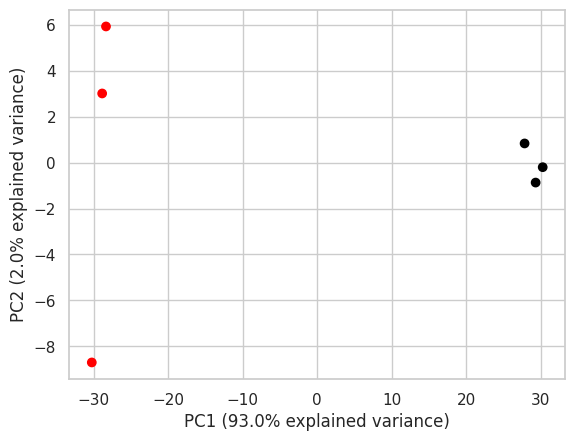

In [15]:
plt.scatter(pca_result[:, 0], pca_result[:, 1], c = ["red"] * 3 + ["black"] * 3)
plt.xlabel("PC1 ({}% explained variance)".format(explained_variance[0]))
plt.ylabel("PC2 ({}% explained variance)".format(explained_variance[1]))
plt.show()

## Differential gene expression analysis

In [16]:
# Compute stats
statistics = DeseqStats(dds, contrast = ["Condition", "producer", "host"])
statistics.summary()

results = statistics.results_df

Running Wald tests...
... done in 12.02 seconds.



Log2 fold change & Wald test p-value: Condition producer vs host
            baseMean  log2FoldChange     lfcSE      stat        pvalue  \
gene_id                                                                  
Aaas     1862.773404       -0.192889  0.055745 -3.460224  5.397265e-04   
Aacs     2840.571188        0.105306  0.068831  1.529931  1.260338e-01   
Aagab    1669.163337        0.110238  0.061930  1.780043  7.506900e-02   
Aak1     2302.560428        0.068598  0.059400  1.154853  2.481506e-01   
Aamdc     288.524728       -0.693886  0.116496 -5.956322  2.579779e-09   
...              ...             ...       ...       ...           ...   
Zxdc     1317.222548        0.231647  0.064921  3.568147  3.595154e-04   
Zyg11b   3043.463039       -0.251051  0.050714 -4.950376  7.407008e-07   
Zyx       704.195019       -0.048875  0.087926 -0.555864  5.783039e-01   
Zzef1     889.800942       -0.129701  0.089774 -1.444748  1.485287e-01   
Zzz3     6629.932760        0.144687  0.040143 

Significantly differentially expressed genes are defined as
$$
p_{adj} < 0.05
$$
and
$$
|\log_2FC| > 1.
$$


In [17]:
significance_level = 0.05
fc_cutoff = 1

In [18]:
significant_results = results.query("padj < 0.05 & log2FoldChange.abs() > 1")

In [19]:
def define_significance(gene):
    if gene["padj"] < significance_level and gene["log2FoldChange"] > fc_cutoff:
        return "up"
    elif gene["padj"] < significance_level and gene["log2FoldChange"] < -fc_cutoff:
        return "down"
    else:
        return "ns"

results["regulation"] = results.apply(define_significance, axis = 1)
results["regulation"].value_counts()

,count
regulation,
ns,10915
down,747
up,554


In [20]:
results[results["regulation"] == "up"].to_csv("producer_vs_host_upregulated_genes.csv")
results[results["regulation"] == "down"].to_csv("producer_vs_host_downregulated_genes.csv")

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


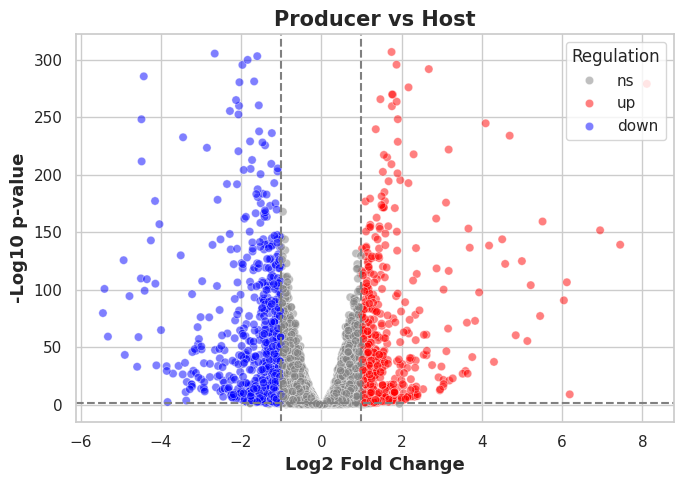

In [22]:
#volcano plot
plt.figure(figsize=(7,5))
sns.scatterplot(
    x = 'log2FoldChange',
    y = -np.log10(results['padj']),
    data = results, hue='regulation',
    palette = {'up': 'red','down': 'blue', 'ns': 'grey'},
    alpha=0.5
)
plt.title('Producer vs Host', fontsize=15, weight='bold')
plt.xlabel('Log2 Fold Change', fontsize=13, weight='bold')
plt.ylabel('-Log10 p-value', fontsize=13, weight='bold')
plt.axhline(y = -np.log10(significance_level), color='grey', linestyle='--')
plt.axvline(x = fc_cutoff, color='grey', linestyle='--')
plt.axvline(x = -fc_cutoff, color='grey', linestyle='--')
plt.legend(title = 'Regulation')
plt.tight_layout()
plt.show()

## **Functional Enrichment Analysis**

In [23]:
!pip install gseapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 634.7/634.7 kB 32.6 MB/s eta 0:00:00


In [31]:
import gseapy

In [68]:
orthologs = pd.read_csv("https://raw.githubusercontent.com/NBorthLab/ESACT2026_Transcriptome_Workshop/refs/heads/main/orthos.csv")
orthologs = orthologs.set_index("hamster")

In [73]:
results_ortho = results.join(orthologs)

In [82]:
background_genes = results_ortho.mouse.dropna().to_list()

upregulated_genes = results_ortho.query("regulation == 'up'")

downregulated_genes = results_ortho.query("regulation == 'down'")

In [112]:
go_enrich_downreg = gseapy.enrichr(
    gene_list = downregulated_genes.mouse.dropna(),
    gene_sets = ["./GO_Biological_Process_2026.gmt", "./KEGG_2019_Mouse.gmt"],
    background = background_genes,
    outdir = None,
    cutoff = 0.05,
    verbose = True
)

go_enrich_downreg.results.sort_values(by = "Adjusted P-value").head()

2026-06-01 11:49:21,498 [INFO] User defined gene sets is given: ./GO_Biological_Process_2026.gmt
2026-06-01 11:49:21,538 [INFO] User defined gene sets is given: ./KEGG_2019_Mouse.gmt
2026-06-01 11:49:21,548 [INFO] Off-line enrichment analysis with library: GO_Biological_Process_2026.gmt
2026-06-01 11:49:21,552 [INFO]   Genes in GMT file are all in upper case, convert query to upper case.
2026-06-01 11:49:22,687 [INFO] Off-line enrichment analysis with library: KEGG_2019_Mouse.gmt
2026-06-01 11:49:22,692 [INFO]   Genes in GMT file are all in upper case, convert query to upper case.
2026-06-01 11:49:22,813 [INFO] Done.


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
409,GO_Biological_Process_2026.gmt,Extracellular Matrix Organization (GO:0030198),24/75,1.931493e-13,4.718636e-10,9.048925,264.910102,PLOD1;ADAMTS4;BMP1;QSOX1;LOXL2;P3H4;MMP19;COL8...
793,GO_Biological_Process_2026.gmt,Negative Regulation of Blood Coagulation (GO:0...,6/8,4.931095e-07,5.293243e-04,47.896834,695.583421,PLAT;TFPI;PDGFRA;SERPINE1;C1QTNF1;THBD
410,GO_Biological_Process_2026.gmt,Extracellular Structure Organization (GO:0043062),11/34,6.500094e-07,5.293243e-04,9.086775,129.452734,ADAMTS4;COL8A1;MMP19;MMP11;ADAMTS7;TGFBR1;MMP2...
275,GO_Biological_Process_2026.gmt,Collagen Fibril Organization (GO:0030199),9/24,1.684613e-06,1.028877e-03,11.344064,150.807701,PLOD1;BMP1;TGFBR1;COL12A1;FBN1;LOXL2;P3H4;COL5...
163,GO_Biological_Process_2026.gmt,Cell-matrix Adhesion (GO:0007160),13/55,3.392693e-06,1.657670e-03,5.910210,74.432519,THBS3;ITGA7;FN1;SORBS1;ACTN3;FERMT2;ITGA3;SGCE...


<Axes: xlabel='Combined Score'>

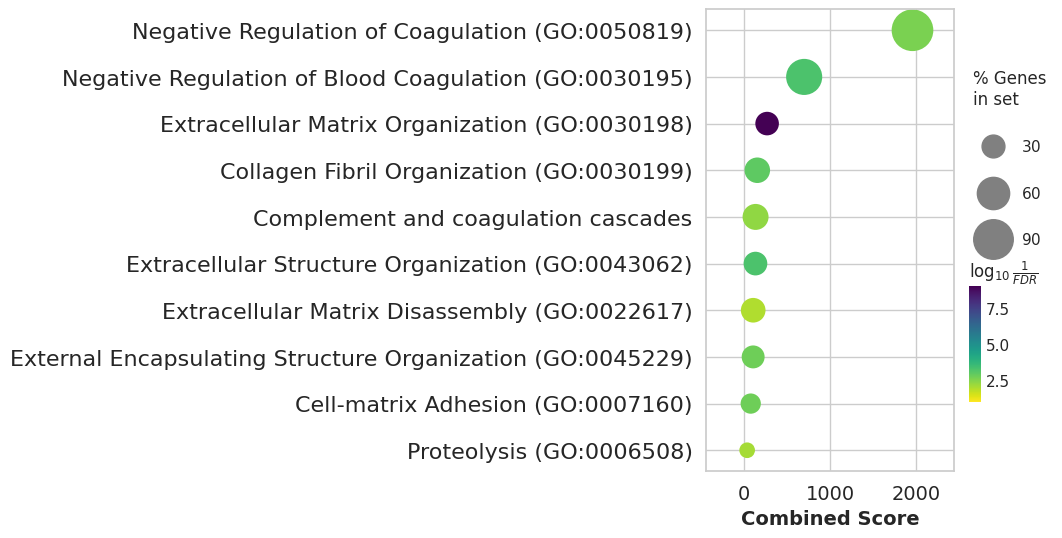

In [107]:
gseapy.dotplot(go_enrich_downreg.results)

In [111]:
go_enrich_upreg = gseapy.enrichr(
    gene_list = upregulated_genes.mouse.dropna(),
    gene_sets = ["./GO_Biological_Process_2026.gmt", "./KEGG_2019_Mouse.gmt"],
    background = background_genes,
    outdir = None,
    cutoff = 0.05,
    verbose = True
)

go_enrich_upreg.results.sort_values(by = "Adjusted P-value").head()

2026-06-01 11:49:10,529 [INFO] User defined gene sets is given: ./GO_Biological_Process_2026.gmt
2026-06-01 11:49:10,572 [INFO] User defined gene sets is given: ./KEGG_2019_Mouse.gmt
2026-06-01 11:49:10,579 [INFO] Off-line enrichment analysis with library: GO_Biological_Process_2026.gmt
2026-06-01 11:49:10,580 [INFO]   Genes in GMT file are all in upper case, convert query to upper case.
2026-06-01 11:49:11,543 [INFO] Off-line enrichment analysis with library: KEGG_2019_Mouse.gmt
2026-06-01 11:49:11,545 [INFO]   Genes in GMT file are all in upper case, convert query to upper case.
2026-06-01 11:49:11,713 [INFO] Done.


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
1172,GO_Biological_Process_2026.gmt,Positive Regulation of Cell Differentiation (G...,22/168,0.000003,0.006421,3.551051,45.359554,SMYD1;ID2;SMARCD3;CD36;MEDAG;ZFP36L1;AGT;PKDCC...
2469,KEGG_2019_Mouse.gmt,Thyroid hormone synthesis,7/29,0.000177,0.039586,7.522567,65.001880,CREB1;HSP90B1;SLC5A5;IYD;PDIA4;GPX1;HSPA5
2390,KEGG_2019_Mouse.gmt,Neuroactive ligand-receptor interaction,8/43,0.000420,0.047018,5.409240,42.060733,C3;APLN;GPR156;CHRNB2;ADM;PTGER4;AGT;PRLR
2462,KEGG_2019_Mouse.gmt,TGF-beta signaling pathway,9/58,0.000752,0.056118,4.339866,31.218071,ID2;SMAD6;RGMA;BMPR1B;BAMBI;DCN;ID3;SMURF1;BMPR2
942,GO_Biological_Process_2026.gmt,Negative Regulation of Osteoblast Differentiat...,7/26,0.000083,0.062886,8.682752,81.558339,NOTCH1;SMAD6;RANBP3L;BAMBI;SKI;TWIST2;SMURF1


<Axes: xlabel='Combined Score'>

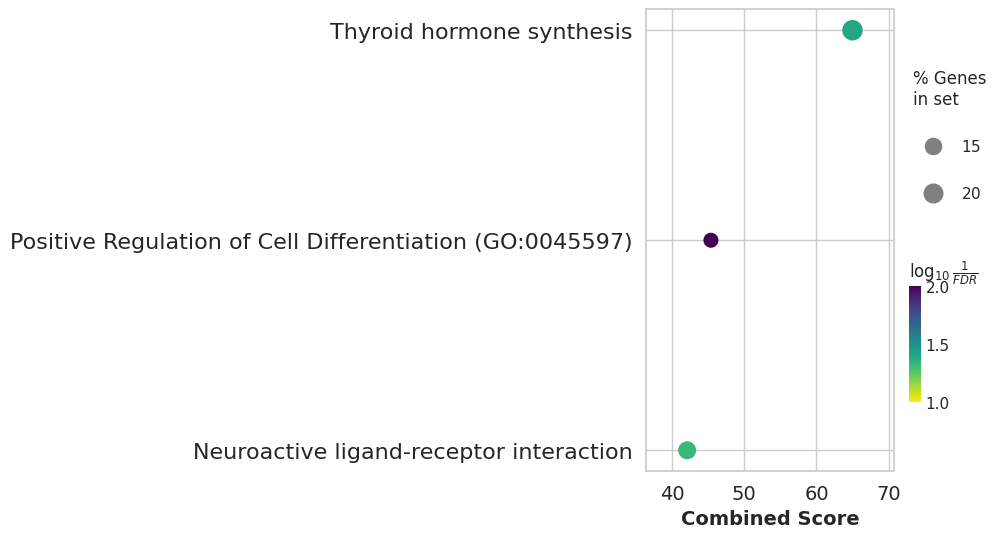

In [109]:
gseapy.dotplot(go_enrich_upreg.results)